# Boosting

Boosting is an ensemble method designed to improve the performance of weak learners by combining them sequentially into a strong composite model. The core idea is that each new model focuses more on the mistakes made by the previous ones, allowing the overall ensemble to correct itself over time.

In this notebook, we implemented AdaBoost (Adaptive Boosting) for binary classification. The outline of this algorithm is:

#### Initialize Sample Weights

All training samples are assigned equal weights at the start.

#### Train Weak Learners Sequentially

For each boosting round a weak learner (in this case, a decision stump) is trained on the weighted dataset. The model predicts the training data, and its error rate is calculated as the total weight of the misclassified samples.

#### Compute Learner Weight (Alpha)

The learner is given a weight based on its error:

$\alpha = \frac{1}{2} \ln \left(\frac{1 - \epsilon}{\epsilon}\right)$

Where $\epsilon$ is the error. This ensures that better-performing learners have more influence in the final decision.

#### Update Sample Weights

Misclassified samples have their weights increased, forcing the next learner to pay more attention to these hard cases.

Weights are normalized to maintain a valid probability distribution.

#### Final Prediction

The ensemble makes a prediction by combining all weak learners’ outputs, weighted by their respective $\alpha$, using a weighted majority vote.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import AdaBoostClassifier

We’ll use the Breast Cancer Wisconsin dataset from sklearn.datasets

This dataset contains information about tumors, including whether they are malignant or benign, based on various features extracted from cell nuclei.

For simplicity and visualization purposes, we’ll focus on just two features:

- Mean Radius

- Mean Texture

These features create a 2D feature space, where we can visually inspect how the boosting works on the data. While this choice limits visualization of the full predictive power of the dataset, it allows us to clearly observe the decision boundaries and interpret the classification results. 

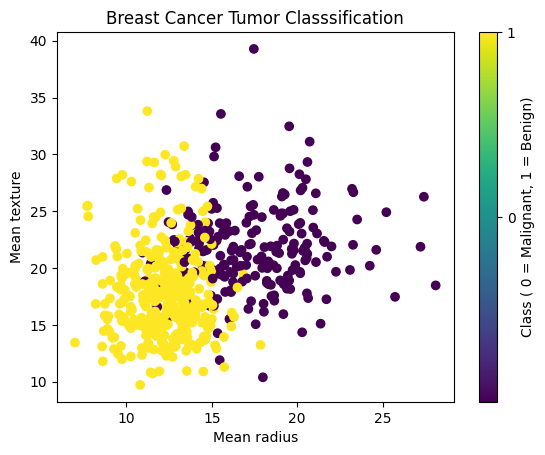

In [2]:
#Loading data
data = load_breast_cancer()
X, y = data.data, data.target
y = np.where(y == 0, -1, 1) #Preparing for boost
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis')  # Pick two features to plot
plt.xlabel('Mean radius')
plt.ylabel('Mean texture')
plt.title('Breast Cancer Tumor Classsification')

cbar = plt.colorbar()
cbar.set_ticks([0, 1])
cbar.set_label('Class ( 0 = Malignant, 1 = Benign)')

plt.show()

In [3]:
class SimpleDecisionStump:
    """A simple decision stump (1-level decision tree) for binary classification."""
    def __init__(self):
        self.feature_index = None
        self.threshold = None
        self.polarity = 1
        self.alpha = None

    def predict(self, X):
        n_samples = X.shape[0]
        X_column = X[:, self.feature_index]
        preds = np.ones(n_samples)
        if self.polarity == 1:
            preds[X_column < self.threshold] = -1
        else:
            preds[X_column > self.threshold] = -1
        return preds

class SimpleAdaBoost:
    def __init__(self, n_estimators=50):
        self.n_estimators = n_estimators
        self.stumps = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        # Initialize weights equally
        w = np.full(n_samples, 1 / n_samples)

        self.stumps = []

        for _ in range(self.n_estimators):
            stump = SimpleDecisionStump()
            min_error = float('inf')

            # Search for best stump
            for feature_i in range(n_features):
                thresholds = np.unique(X[:, feature_i])
                for threshold in thresholds:
                    for polarity in [1, -1]:
                        preds = np.ones(n_samples)
                        if polarity == 1:
                            preds[X[:, feature_i] < threshold] = -1
                        else:
                            preds[X[:, feature_i] > threshold] = -1
                        misclassified = w[y != preds]
                        error = sum(misclassified)

                        if error < min_error:
                            min_error = error
                            stump.feature_index = feature_i
                            stump.threshold = threshold
                            stump.polarity = polarity

            # Compute alpha (learner weight)
            EPS = 1e-10  # to avoid division by zero
            stump.alpha = 0.5 * np.log((1 - min_error + EPS) / (min_error + EPS))

            # Update sample weights
            preds = stump.predict(X)
            w *= np.exp(-stump.alpha * y * preds)
            w /= np.sum(w)  # normalize

            # Save the stump
            self.stumps.append(stump)

    def predict(self, X):
        stump_preds = np.array([stump.alpha * stump.predict(X) for stump in self.stumps])
        y_pred = np.sign(np.sum(stump_preds, axis=0))
        return (y_pred + 1) // 2  # Convert back to {0, 1}

In [4]:
# Implement Boost
ada = SimpleAdaBoost(n_estimators=20)
ada.fit(X_train, y_train)
y_pred = ada.predict(X_test)
y_test_original = (y_test + 1) // 2  # Reversing the prep
accuracy = accuracy_score(y_test_original, y_pred)
print(f"Custom Boosting Accuracy: {accuracy:.4f}")

Custom Boosting Accuracy: 0.9737


In [5]:
# Implement sklearn Boost
sklearn_ada = AdaBoostClassifier(n_estimators=20)
sklearn_ada.fit(X_train, (y_train + 1) // 2)
y_pred_sklearn = sklearn_ada.predict(X_test)
accuracy_sklearn = accuracy_score((y_test + 1) // 2, y_pred_sklearn)
print(f"Sklearn Boosting Accuracy: {accuracy_sklearn:.4f}")

Sklearn Boosting Accuracy: 0.9649


In [6]:
#Comparing Results
print("\nComparison:")
print(f"Custom Boosting correct: {(y_pred == y_test_original).sum()} / {len(y_test)}")
print(f"Sklearn Boosting correct: {(y_pred_sklearn == y_test_original).sum()} / {len(y_test)}")


Comparison:
Custom Boosting correct: 111 / 114
Sklearn Boosting correct: 110 / 114


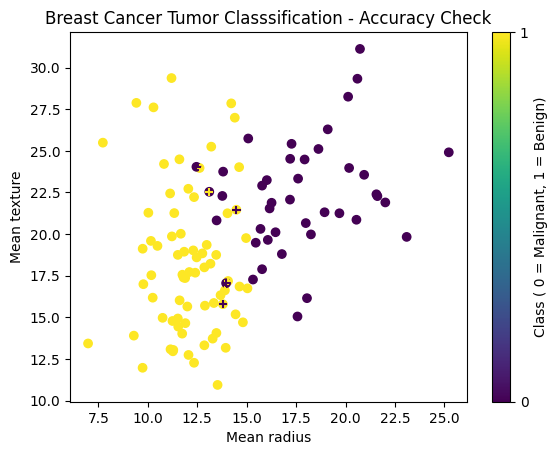

In [7]:
plt.scatter(X_test[:, 0], X_test[:, 1], c = y_pred)
plt.scatter(X_test[:, 0], X_test[:, 1], c = y_test_original, marker = '+')

plt.xlabel('Mean radius')
plt.ylabel('Mean texture')
plt.title('Breast Cancer Tumor Classsification - Accuracy Check')

cbar = plt.colorbar()
cbar.set_ticks([0, 1])
cbar.set_label('Class ( 0 = Malignant, 1 = Benign)')

This result really showcases the purpose of boosting, as this algorithm performed better than the single decision tree model, as expected. It also performed better than the random forest, which is quite interesting.

Our boosting algorithm has accuracy comparable to the sklearn model, surpassing it at times!